<a href="https://colab.research.google.com/github/apurvapm/Bird-Image-Recognizer-CUB/blob/main/CUB_EF~1_IPY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-tune EfficientNet on CUB-200-2011

Trains EfficientNet-B0 (ImageNet-pretrained) on the 200 bird species in CUB-200-2011, end to end on a Colab GPU.

**Before running:** Runtime → Change runtime type → T4 GPU.

Run cells top to bottom. Expect ~5–10 minutes for the full training run on a T4.


In [1]:
import torch, torchvision
print("torch       :", torch.__version__)
print("torchvision :", torchvision.__version__)
print("CUDA        :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


torch       : 2.10.0+cu128
torchvision : 0.25.0+cu128
CUDA        : True
GPU         : Tesla T4


## 1. Download CUB-200-2011 (~1.1 GB, one-time)

In [2]:
!mkdir -p /content/data
!wget -q -c -O /content/data/CUB_200_2011.tgz https://data.caltech.edu/records/65de6-vp158/files/CUB_200_2011.tgz
!ls -lh /content/data/CUB_200_2011.tgz


-rw-r--r-- 1 root root 1.1G Sep  8  2022 /content/data/CUB_200_2011.tgz


In [3]:
import tarfile, os
from pathlib import Path
CUB_ROOT = Path("/content/data/CUB_200_2011")
if not (CUB_ROOT / "images.txt").exists():
    print("Extracting...")
    with tarfile.open("/content/data/CUB_200_2011.tgz", "r:gz") as tf:
        tf.extractall("/content/data")
print("CUB files:", sorted(os.listdir(CUB_ROOT))[:8])


Extracting...


/tmp/ipykernel_4739/191906861.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall("/content/data")


CUB files: ['README', 'attributes', 'bounding_boxes.txt', 'classes.txt', 'image_class_labels.txt', 'images', 'images.txt', 'parts']


## 2. Dataset class + transforms

In [4]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

def _read_id_map(path, cast=str):
    out = {}
    for line in open(path):
        a, _, b = line.strip().partition(" ")
        if a:
            out[int(a)] = cast(b)
    return out

def load_class_names(root=CUB_ROOT):
    raw = _read_id_map(root / "classes.txt")
    return [raw[i + 1].split(".", 1)[1].replace("_", " ") for i in range(200)]

class CUBDataset(Dataset):
    def __init__(self, root, train=True, transform=None):
        self.root, self.transform = Path(root), transform
        paths = _read_id_map(self.root / "images.txt")
        labels = _read_id_map(self.root / "image_class_labels.txt", int)
        split = _read_id_map(self.root / "train_test_split.txt", int)
        want = 1 if train else 0
        self.samples = [
            (self.root / "images" / paths[i], labels[i] - 1)
            for i in paths if split[i] == want
        ]
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, i):
        p, y = self.samples[i]
        img = Image.open(p).convert("RGB")
        return self.transform(img) if self.transform else img, y

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])


In [5]:
train_ds = CUBDataset(CUB_ROOT, train=True,  transform=train_tf)
val_ds   = CUBDataset(CUB_ROOT, train=False, transform=eval_tf)
class_names = load_class_names()
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Classes: {len(class_names)}")

BATCH = 32
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)


Train: 5994 | Val: 5794 | Classes: 200


## 3. Peek at a batch

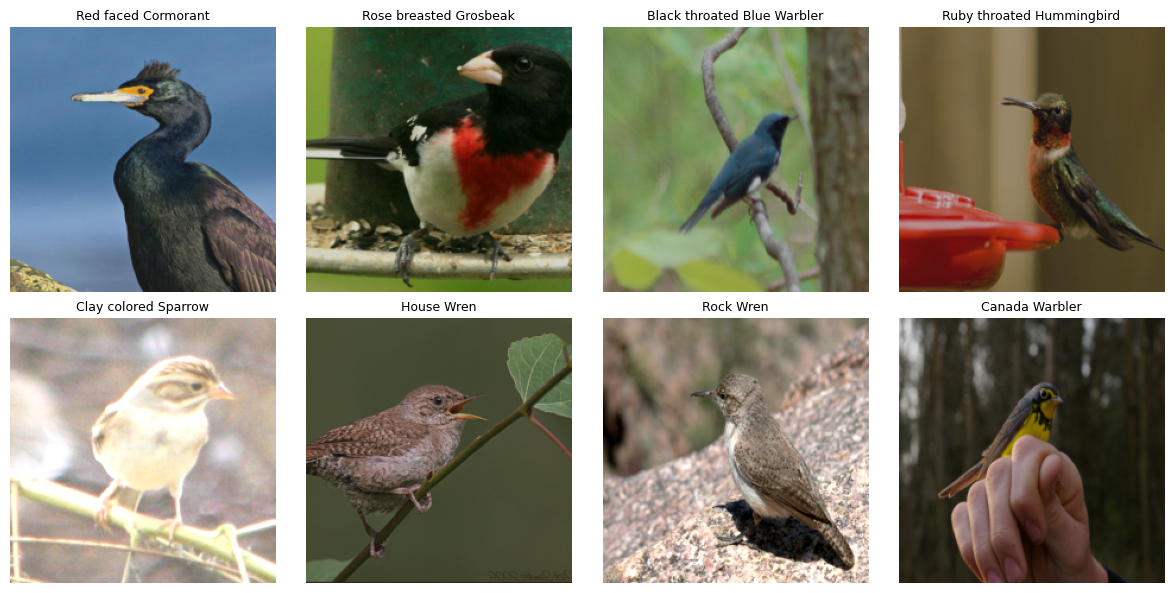

In [6]:
import matplotlib.pyplot as plt

def unnormalize(t):
    t = t.clone()
    for c, (m, s) in enumerate(zip(MEAN, STD)):
        t[c] = t[c] * s + m
    return t.clamp(0, 1).permute(1, 2, 0).numpy()

xs, ys = next(iter(DataLoader(train_ds, batch_size=8, shuffle=True)))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, img, label in zip(axes.flat, xs, ys):
    ax.imshow(unnormalize(img))
    ax.set_title(class_names[label.item()], fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()


## 4. Build EfficientNet-B0 with a fresh 200-class head

In [7]:
import torch.nn as nn
from torchvision import models

def build_model(num_classes=200, freeze=False):
    m = models.efficientnet_b0(weights="DEFAULT")
    in_f = m.classifier[-1].in_features
    m.classifier[-1] = nn.Linear(in_f, num_classes)
    if freeze:
        for p in m.parameters():
            p.requires_grad = False
        for p in m.classifier[-1].parameters():
            p.requires_grad = True
    return m

# With a GPU we go full fine-tune (set freeze=True for CPU / quick demo).
model = build_model(num_classes=200, freeze=False).to(device)
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {n_train:,} / {n_total:,} ({100*n_train/n_total:.1f}%)")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 89.8MB/s]


Trainable params: 4,263,748 / 4,263,748 (100.0%)


## 5. Train

In [8]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.auto import tqdm

EPOCHS = 10
LR     = 3e-4
WD     = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = AdamW([p for p in model.parameters() if p.requires_grad],
                  lr=LR, weight_decay=WD)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    # ---- train ----
    model.train()
    tl = tc = tn = 0
    pbar = tqdm(train_loader, desc=f"epoch {epoch}/{EPOCHS}")
    for x, y in pbar:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        tl += loss.item() * x.size(0)
        tc += (out.argmax(1) == y).sum().item()
        tn += x.size(0)
        pbar.set_postfix(loss=f"{tl/tn:.3f}", acc=f"{tc/tn:.3f}")
    train_loss, train_acc = tl / tn, tc / tn

    # ---- validate ----
    model.eval()
    vl = vc = vn = 0
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device); y = y.to(device)
            out = model(x); loss = criterion(out, y)
            vl += loss.item() * x.size(0)
            vc += (out.argmax(1) == y).sum().item()
            vn += x.size(0)
    val_loss, val_acc = vl / vn, vc / vn
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    print(f"[{epoch:02d}]  train_loss={train_loss:.3f}  train_acc={train_acc:.3f}  "
          f"val_loss={val_loss:.3f}  val_acc={val_acc:.3f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({
            "state_dict":  model.state_dict(),
            "class_names": class_names,
            "model_name":  "efficientnet_b0",
            "val_acc":     val_acc,
            "epoch":       epoch,
        }, "/content/best.pt")
        print(f"  -> new best val_acc {val_acc:.4f}, saved /content/best.pt")

print(f"\nDone. Best val_acc = {best_acc:.4f}")


epoch 1/10:   0%|          | 0/187 [00:00<?, ?it/s]

[01]  train_loss=3.993  train_acc=0.201  val_loss=2.203  val_acc=0.533
  -> new best val_acc 0.5331, saved /content/best.pt


epoch 2/10:   0%|          | 0/187 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79aca95acc20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79aca95acc20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

[02]  train_loss=1.747  train_acc=0.597  val_loss=1.267  val_acc=0.687
  -> new best val_acc 0.6866, saved /content/best.pt


...

[08]  train_loss=0.163  train_acc=0.975  val_loss=0.743  val_acc=0.793
  -> new best val_acc 0.7931, saved /content/best.pt


epoch 9/10:   0%|          | 0/187 [00:00<?, ?it/s]

[09]  train_loss=0.139  train_acc=0.984  val_loss=0.733  val_acc=0.791


epoch 10/10:   0%|          | 0/187 [00:00<?, ?it/s]

[10]  train_loss=0.123  train_acc=0.985  val_loss=0.737  val_acc=0.794
  -> new best val_acc 0.7938, saved /content/best.pt

Done. Best val_acc = 0.7938


## 6. Training curves

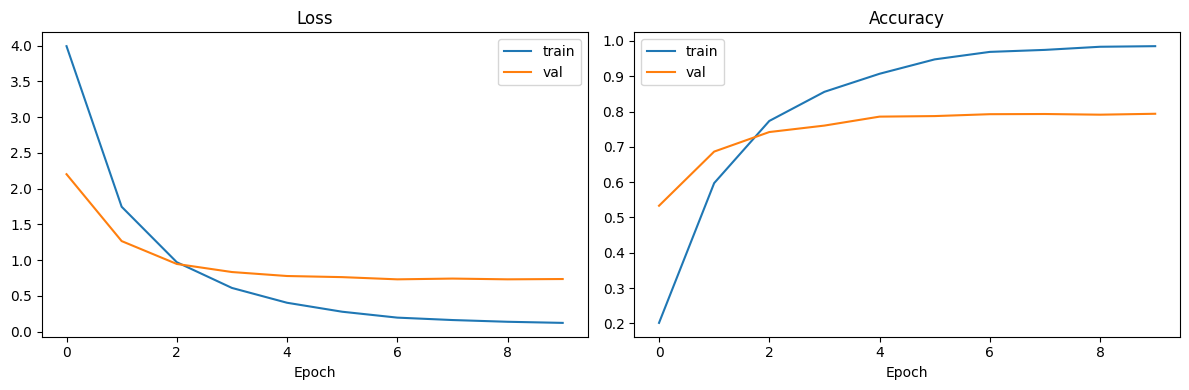

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"],   label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"],   label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout(); plt.show()


## 7. Top-1 / top-5 evaluation on the test set

In [10]:
model.eval()
top1 = top5 = total = 0
with torch.no_grad():
    for x, y in tqdm(val_loader, desc="evaluating"):
        x = x.to(device); y = y.to(device)
        logits = model(x)
        _, pred5 = logits.topk(5, dim=1)
        top1 += (pred5[:, 0] == y).sum().item()
        top5 += (pred5 == y.unsqueeze(1)).any(1).sum().item()
        total += y.size(0)
print(f"Top-1 acc: {top1/total:.4f}")
print(f"Top-5 acc: {top5/total:.4f}")


evaluating:   0%|          | 0/182 [00:00<?, ?it/s]

Top-1 acc: 0.7938
Top-5 acc: 0.9579


building confusion matrix:   0%|          | 0/182 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79aca95acc20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79aca95acc20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

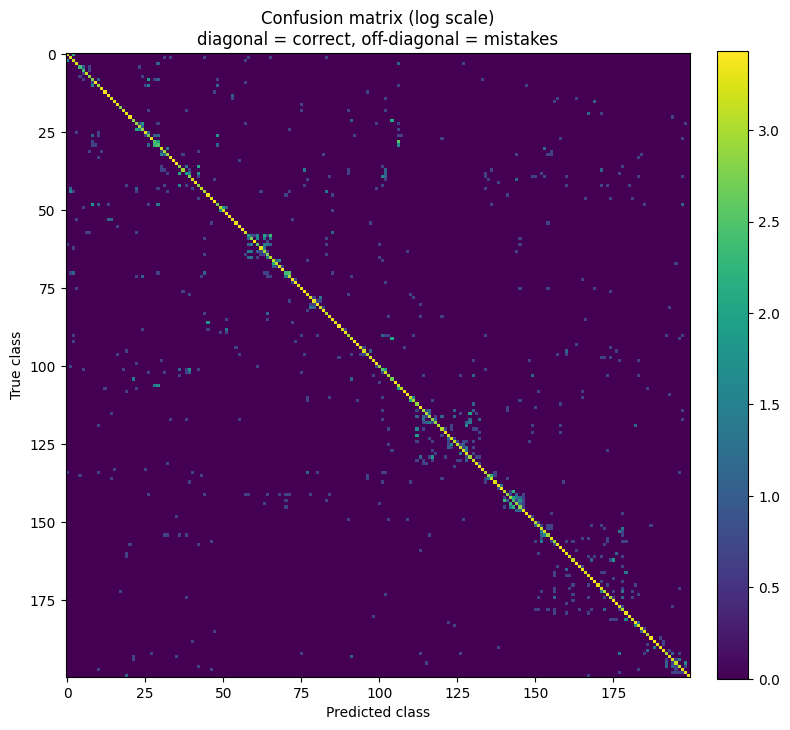

Most-confused pairs (true -> predicted):
  12x   American Crow  ->  Common Raven
  11x   Long tailed Jaeger  ->  Pomarine Jaeger
   9x   Fish Crow  ->  American Crow
   9x   Common Tern  ->  Artic Tern
   9x   California Gull  ->  Western Gull
   8x   Forsters Tern  ->  Common Tern
   8x   Elegant Tern  ->  Caspian Tern
   8x   Barn Swallow  ->  Cliff Swallow
   8x   Artic Tern  ->  Common Tern
   7x   Ruby throated Hummingbird  ->  Anna Hummingbird
   7x   Pelagic Cormorant  ->  Brandt Cormorant
   7x   Nighthawk  ->  Whip poor Will
   7x   Least Flycatcher  ->  Acadian Flycatcher
   7x   Great Grey Shrike  ->  Loggerhead Shrike
   7x   Chuck will Widow  ->  Whip poor Will

Worst-performing species:
  20.0%   California Gull  (n=30)
  20.7%   Least Flycatcher  (n=29)
  33.3%   Long tailed Jaeger  (n=30)
  33.3%   Common Tern  (n=30)
  36.7%   American Crow  (n=30)
  36.7%   Fish Crow  (n=30)
  40.0%   Western Wood Pewee  (n=30)
  40.0%   Herring Gull  (n=30)
  46.7%   Shiny Cowbird  (

In [11]:
# ===== Confusion matrix & error analysis =====
import numpy as np

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in tqdm(val_loader, desc="building confusion matrix"):
        x = x.to(device)
        preds = model(x).argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(y)
all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

n = len(class_names)
cm = np.zeros((n, n), dtype=int)
for t, p in zip(all_labels, all_preds):
    cm[t, p] += 1

plt.figure(figsize=(8, 8))
plt.imshow(np.log1p(cm), cmap="viridis")
plt.title("Confusion matrix (log scale)\ndiagonal = correct, off-diagonal = mistakes")
plt.xlabel("Predicted class"); plt.ylabel("True class")
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

pairs = [(cm[t, p], class_names[t], class_names[p])
         for t in range(n) for p in range(n) if t != p and cm[t, p] > 0]
pairs.sort(reverse=True)
print("Most-confused pairs (true -> predicted):")
for count, true_name, pred_name in pairs[:15]:
    print(f"  {count:2d}x   {true_name}  ->  {pred_name}")

per_class_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
order = np.argsort(per_class_acc)
print("\nWorst-performing species:")
for i in order[:10]:
    print(f"  {per_class_acc[i]:5.1%}   {class_names[i]}  (n={cm[i].sum()})")

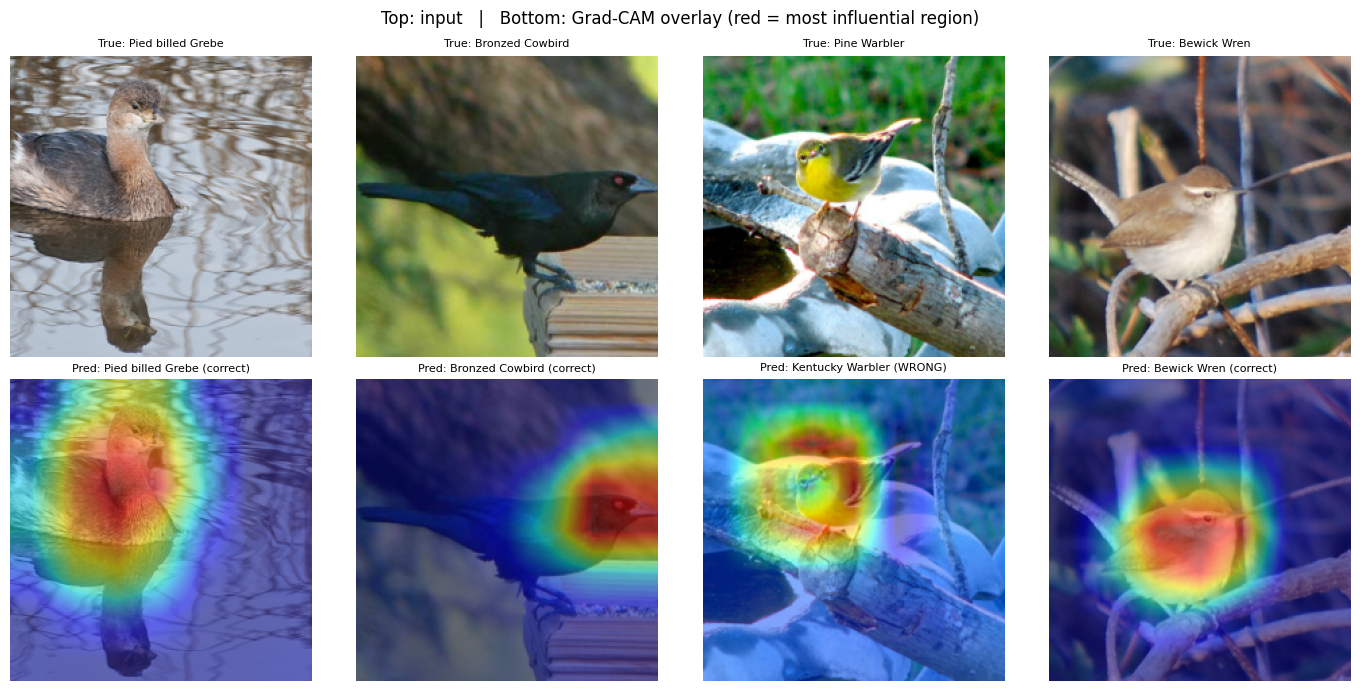

In [12]:
# ===== Grad-CAM: what is the model looking at? =====
import torch.nn.functional as F
import numpy as np
import random

class GradCAM:
    """Gradient-weighted Class Activation Mapping for one target layer."""
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        self.handles = [
            target_layer.register_forward_hook(self._save_activation),
            target_layer.register_full_backward_hook(self._save_gradient),
        ]
    def _save_activation(self, module, inp, out):
        self.activations = out.detach()
    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()
    def __call__(self, x, class_idx=None):
        self.model.eval()
        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(1).item()
        self.model.zero_grad()
        logits[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(1, keepdim=True))
        cam = F.interpolate(cam, size=x.shape[2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx
    def remove(self):
        for h in self.handles:
            h.remove()

gradcam = GradCAM(model, model.features[-1])

idxs = random.sample(range(len(val_ds)), 4)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for col, idx in enumerate(idxs):
    img_tensor, true_label = val_ds[idx]
    x = img_tensor.unsqueeze(0).to(device)
    cam, pred_idx = gradcam(x)
    orig = unnormalize(img_tensor)

    axes[0, col].imshow(orig)
    axes[0, col].set_title(f"True: {class_names[true_label]}", fontsize=8)
    axes[0, col].axis("off")

    axes[1, col].imshow(orig)
    axes[1, col].imshow(cam, cmap="jet", alpha=0.5)
    mark = "correct" if pred_idx == true_label else "WRONG"
    axes[1, col].set_title(f"Pred: {class_names[pred_idx]} ({mark})", fontsize=8)
    axes[1, col].axis("off")

plt.suptitle("Top: input   |   Bottom: Grad-CAM overlay (red = most influential region)")
plt.tight_layout(); plt.show()
gradcam.remove()

## 8. Predict on an uploaded photo

In [ ]:
from google.colab import files
import io

uploaded = files.upload()  # opens a file picker
for fname, data in uploaded.items():
    img = Image.open(io.BytesIO(data)).convert("RGB")
    x = eval_tf(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(x), dim=1)[0]
    top_p, top_i = probs.topk(5)

    plt.figure(figsize=(5, 5))
    plt.imshow(img); plt.axis("off"); plt.title(fname); plt.show()
    print(f"\nTop 5 predictions for {fname}:")
    for p, i in zip(top_p, top_i):
        bar = "#" * int(round(p.item() * 30))
        print(f"  {class_names[i]:<35s} {p.item():6.2%}  {bar}")


In [13]:
from google.colab import drive
import shutil

drive.mount("/content/drive")
DRIVE_DIR = "/content/drive/MyDrive/cub_efficientnet"
os.makedirs(DRIVE_DIR, exist_ok=True)
shutil.copy("/content/best.pt", f"{DRIVE_DIR}/best.pt")
print(f"Saved to {DRIVE_DIR}/best.pt")


--- Logging error ---


KeyboardInterrupt: 

## Next steps

- Try `models.efficientnet_b2` or `b3` for higher accuracy (slower, more VRAM).
- Edit `train_tf` to add `transforms.RandAugment()` or `AutoAugment(transforms.AutoAugmentPolicy.IMAGENET)`.
- Compare `freeze=True` vs `freeze=False` accuracy and training time — great visualization of why transfer learning matters.
- Plug the saved `best.pt` into the sister `bird_id` Gradio app for a polished demo.
